# 03c · Fraud Analytics Chapter 4 — Predictive Analytics for Fraud Detection
*Every concept of the chapter, in book order, each with an explanation, a worked example and code.* Where the book gives numbers (scorecard scaling, Pluto–Tasche probabilities, SMOTE example, posterior adjustment) the code **reproduces them first**.

| # | Concept | # | Concept |
|---|---|---|---|
| 1 | Target definition | 8 | Ensemble methods (bagging, boosting, random forests) |
| 2 | Linear regression | 9 | Multiclass classification |
| 3 | Logistic regression (+ scorecard) | 10 | Evaluating predictive models (splits, classification & regression measures) |
| 4 | Variable selection (linear & logistic) | 11 | Skewed data sets (sampling, SMOTE, likelihood approach, posteriors, costs) |
| 5 | Decision trees | 12 | Fraud performance benchmarks |
| 6 | Neural networks (+ opening the black box) | | |
| 7 | Support vector machines (+ opening the black box) | | |

Two data sets: **card-not-present transactions** (label = chargeback, 0.45 % fraud; out-of-time split at day 255) and **customers** (label = oracle, lab only).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings, itertools, time
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy import stats, optimize
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict, cross_val_score, LeaveOneOut, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, confusion_matrix, precision_recall_fscore_support, f1_score, r2_score,
                             mean_squared_error, mean_absolute_error, accuracy_score)
import amlkit as ak

pd.set_option("display.float_format", "{:,.4f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(0)
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); feat = pd.read_pickle(ak.PROC / "features.pkl")
cards = ak.card_features(txn[txn.channel == "card_online"]); F = ak.CARD_FEATURES
trn, tst = cards[cards.day < 255], cards[cards.day >= 255]
Xtr, ytr, Xte, yte = trn[F], trn.is_fraud.values, tst[F], tst.is_fraud.values
sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print(f"card train {len(trn):,} ({ytr.sum()} fraud) | test {len(tst):,} ({yte.sum()} fraud) | features: {F}")

card train 59,029 (243 fraud) | test 25,434 (140 fraud) | features: ['log_amt', 'hour', 'night', 'foreign', 'new_device', 'amt_z', 'log_hrs_since_prev', 'n_prev_1h', 'n_prev_24h']


## 1 · Target definition
The target is rarely clean in fraud: one can **never be fully sure** a transaction/claim/company is fraudulent. Labels come from investigations, court rulings or chargebacks — imperfect, delayed, and biased by *what was worth investigating*. Examples in the chapter: insurance claims (small claims are not pursued even if fraudulent) and the tax-evasion **spider construction** (all fraudulent companies go bankrupt, but not all bankruptcies are fraud). The target can be **binary** (fraud yes/no) or **continuous** (fraud amount — itself hard to define: direct/indirect cost, reputation, time value). *Consequence:* models must **tolerate label noise**.

Experiment: hide a share of the true frauds (they are labelled "genuine" in training because nobody detected them), then evaluate against the *true* labels.

In [2]:
rows = []
for miss in [0, 0.1, 0.3, 0.5, 0.7]:
    yn = ytr.copy(); idx = np.flatnonzero(yn == 1); yn[rng.choice(idx, int(miss * len(idx)), replace=False)] = 0
    p = LogisticRegression(max_iter=2000).fit(Xtr_s, yn).predict_proba(Xte_s)[:, 1]
    rows.append(dict(undetected_frauds_in_training=miss, AUC_true_labels=roc_auc_score(yte, p), avg_precision=average_precision_score(yte, p)))
display(pd.DataFrame(rows).set_index("undetected_frauds_in_training"))
print("Ranking (AUC) is fairly robust to missing labels; precision-type measures and calibrated probabilities degrade first.")

,AUC_true_labels,avg_precision
undetected_frauds_in_training,,
0.0000,0.9464,0.7107
0.1000,0.9443,0.7040
0.3000,0.9412,0.6914
0.5000,0.9408,0.6847
0.7000,0.9322,0.6710


Ranking (AUC) is fairly robust to missing labels; precision-type measures and calibrated probabilities degrade first.


## 2 · Linear regression
The most common technique for a **continuous target** — e.g. the *amount* of a fraud. **Y = β₀ + β₁X₁ + … + β_kX_k + ε**, estimated by ordinary least squares (minimise Σ(yᵢ − ŷᵢ)²). Inference: t-test on each coefficient, **R²** and adjusted R², residual analysis (assumptions: linearity, constant variance, independent, roughly normal errors). Below: predict the (log) amount of confirmed card frauds from *behavioural* variables (the amount itself is excluded).

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.9897      0.215     23.186      0.000       4.566       5.414
foreign               -0.1877      0.125     -1.496      0.136      -0.435       0.059
night                  0.0224      0.132      0.170      0.865      -0.238       0.282
new_device             0.1254      0.119      1.051      0.294      -0.110       0.361
hour                   0.0036      0.009      0.392      0.695      -0.015       0.022
n_prev_1h             -0.0497      0.121     -0.411      0.682      -0.288       0.189
n_prev_24h             0.0477      0.136      0.350      0.727      -0.221       0.316
log_hrs_since_prev    -0.0009      0.032     -0.030      0.976      -0.064       0.062
R2 = 0.014, adjusted R2 = -0.015, F-test p = 0.84
TEST: R2 = -0.029 | RMSE = 0.902 | correlation = -0.024


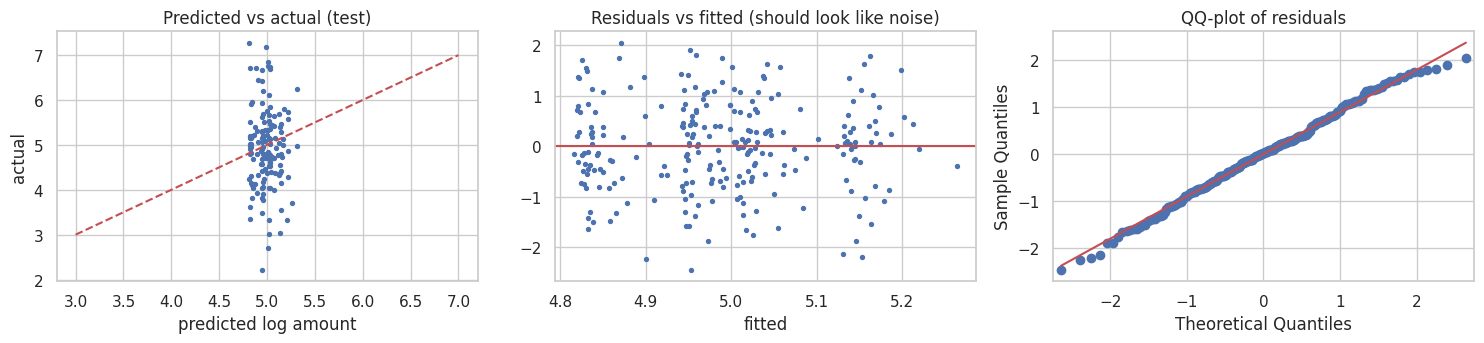

In [3]:
Xf = ["foreign", "night", "new_device", "hour", "n_prev_1h", "n_prev_24h", "log_hrs_since_prev"]
fr_tr, fr_te = trn[trn.is_fraud == 1], tst[tst.is_fraud == 1]
ols = sm.OLS(fr_tr.log_amt, sm.add_constant(fr_tr[Xf])).fit()
print(ols.summary().tables[1]); print(f"R2 = {ols.rsquared:.3f}, adjusted R2 = {ols.rsquared_adj:.3f}, F-test p = {ols.f_pvalue:.3g}")
pred = ols.predict(sm.add_constant(fr_te[Xf])); print(f"TEST: R2 = {r2_score(fr_te.log_amt, pred):.3f} | RMSE = {np.sqrt(mean_squared_error(fr_te.log_amt, pred)):.3f} | correlation = {np.corrcoef(pred, fr_te.log_amt)[0, 1]:.3f}")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6)); ax[0].scatter(pred, fr_te.log_amt, s=8); ax[0].plot([3, 7], [3, 7], "r--"); ax[0].set(xlabel="predicted log amount", ylabel="actual", title="Predicted vs actual (test)")
ax[1].scatter(ols.fittedvalues, ols.resid, s=8); ax[1].axhline(0, c="r"); ax[1].set(title="Residuals vs fitted (should look like noise)", xlabel="fitted"); sm.qqplot(ols.resid, line="s", ax=ax[2]); ax[2].set_title("QQ-plot of residuals"); plt.tight_layout(); plt.show()

In [4]:
# Why not use linear regression for a 0/1 target?  (linear probability model)
lpm = LinearRegression().fit(Xtr_s, ytr); pl = lpm.predict(Xte_s)
print(f"linear regression on the binary target: {np.mean(pl < 0):.1%} of predictions are NEGATIVE and {np.mean(pl > 1):.2%} exceed 1 -> not probabilities; this motivates the logistic function")

linear regression on the binary target: 56.3% of predictions are NEGATIVE and 0.09% exceed 1 -> not probabilities; this motivates the logistic function


## 3 · Logistic regression
**Basic concepts.** Model the probability of fraud with the **logistic (sigmoid)** function: **P(fraud|x) = 1 / (1 + e^−(β₀+β₁x₁+…))**, equivalently **log-odds = ln(P/(1−P)) = β₀ + Σβⱼxⱼ** (the *logit*). Estimated by **maximum likelihood**. Other links: **probit** (normal CDF) and **cloglog**; empirically all perform about equally.

**Properties.** Coefficients are additive on the log-odds scale; **e^β = odds ratio** (multiplicative effect on the odds for one unit increase); a Wald **χ² = (β̂ / s.e.(β̂))²** tests H₀: β = 0 (1 degree of freedom); sensitive to outliers/scale; needs no tuning; easy to deploy and explain.

,coef (per 1 SD),std err,Wald chi2,p-value,odds ratio,OR 95% low,OR 95% high
const,-8.0098,0.2009,"1,588.9112",0.0000,0.0003,0.0002,0.0005
log_amt,0.4817,0.1349,12.7466,0.0004,1.6188,1.2426,2.1087
hour,-0.1777,0.0945,3.5317,0.0602,0.8372,0.6956,1.0077
night,0.4623,0.0878,27.7023,0.0000,1.5876,1.3366,1.8859
foreign,0.8336,0.0774,115.9893,0.0000,2.3016,1.9776,2.6787
new_device,0.7364,0.0388,360.3751,0.0000,2.0883,1.9354,2.2533
amt_z,0.1795,0.1310,1.8776,0.1706,1.1966,0.9257,1.5468
log_hrs_since_prev,-0.1659,0.1153,2.0721,0.1500,0.8471,0.6758,1.0618
n_prev_1h,0.5620,0.0559,101.1253,0.0000,1.7542,1.5722,1.9573
n_prev_24h,0.3723,0.0848,19.2606,0.0000,1.4511,1.2288,1.7136


check: Wald chi2 p-value == 2-sided z p-value: True


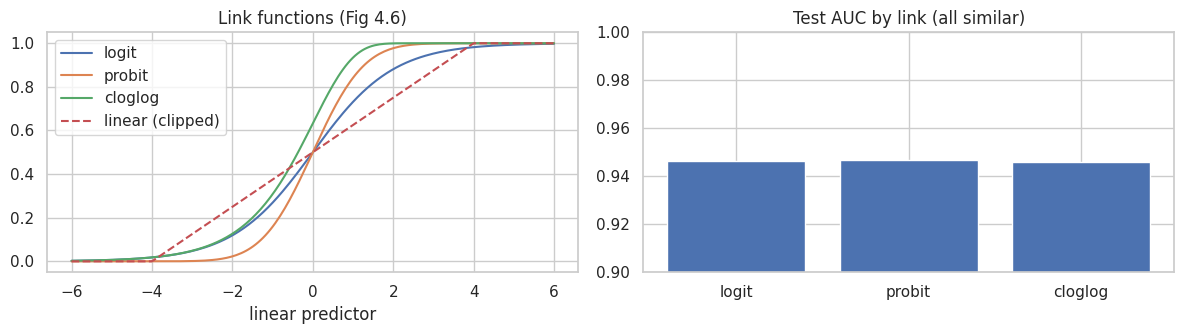

{'logit': 0.9463398999198002, 'probit': 0.9465937715324921, 'cloglog': 0.9459360774435497}


In [5]:
lg = sm.Logit(ytr, sm.add_constant(pd.DataFrame(Xtr_s, columns=F))).fit(disp=0)
tab = pd.DataFrame({"coef (per 1 SD)": lg.params, "std err": lg.bse, "Wald chi2": (lg.params / lg.bse) ** 2, "p-value": lg.pvalues, "odds ratio": np.exp(lg.params),
                    "OR 95% low": np.exp(lg.conf_int()[0]), "OR 95% high": np.exp(lg.conf_int()[1])}); display(tab)
print("check: Wald chi2 p-value == 2-sided z p-value:", np.allclose(stats.chi2.sf(tab["Wald chi2"], 1), lg.pvalues))
z = np.linspace(-6, 6, 200); fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(z, 1 / (1 + np.exp(-z)), label="logit"); ax[0].plot(z, stats.norm.cdf(z), label="probit"); ax[0].plot(z, 1 - np.exp(-np.exp(z)), label="cloglog"); ax[0].plot(z, np.clip(0.5 + z / 8, 0, 1), "--", label="linear (clipped)")
ax[0].set(title="Link functions (Fig 4.6)", xlabel="linear predictor"); ax[0].legend()
Xc_tr, Xc_te = sm.add_constant(pd.DataFrame(Xtr_s, columns=F)), sm.add_constant(pd.DataFrame(Xte_s, columns=F)); aucs = {}
for nm, link in [("logit", sm.families.links.Logit()), ("probit", sm.families.links.Probit()), ("cloglog", sm.families.links.CLogLog())]:
    try: aucs[nm] = roc_auc_score(yte, sm.GLM(ytr, Xc_tr, family=sm.families.Binomial(link=link)).fit().predict(Xc_te))
    except Exception as e: aucs[nm] = np.nan
ax[1].bar(aucs.keys(), aucs.values()); ax[1].set(ylim=(0.9, 1), title="Test AUC by link (all similar)"); plt.tight_layout(); plt.show(); print(aucs)

### Building a logistic-regression **scorecard**
Code the inputs with **weights of evidence** (WoE), so that log-odds = β₀ + β₁WoE₁ + β₂WoE₂ + … Then scale linearly: **Fraud score = Offset + Factor × ln(odds)**. Choose two anchor points, e.g. *score 100 at odds 50:1* and *score 120 at odds 100:1*: **Factor = 20/ln 2 = 28.85; Offset = 100 − Factor·ln 50 ≈ −12.87** (−12.88 unrounded). Points per attribute = **(WoE × β_i + β₀/N) × Factor + Offset/N**. The score is a transparent points table and compared against a cut-off.

In [6]:
factor = 20 / np.log(2); offset = 100 - factor * np.log(50); print(f"Factor = {factor:.2f}, Offset = {offset:.2f}"); assert round(factor, 2) == 28.85 and abs(offset + 12.87) < 0.02          # the book rounds Offset to -12.87
sc_chars = {"foreign": None, "new_device": None, "night": None, "log_hrs_since_prev": 6, "n_prev_1h": "count", "log_amt": 6}
def bin_edges(s, q): e = np.unique(np.quantile(s, np.linspace(0, 1, q + 1))); e[0], e[-1] = -np.inf, np.inf; return e
edges = {c: bin_edges(trn[c], q) for c, q in sc_chars.items() if isinstance(q, int)}
def bin_of(df, c): return pd.cut(df[c], edges[c], labels=False) if c in edges else (df[c].clip(upper=3) if sc_chars[c] == "count" else df[c].astype(int))
woe = {}
for c in sc_chars:
    t = pd.crosstab(bin_of(trn, c), trn.is_fraud) + 0.5; g_, b_ = t[0] / t[0].sum(), t[1] / t[1].sum(); woe[c] = np.log(g_ / b_)
W_tr = pd.DataFrame({c: bin_of(trn, c).map(woe[c]) for c in sc_chars}); W_te = pd.DataFrame({c: bin_of(tst, c).map(woe[c]).fillna(0) for c in sc_chars})
lr_w = LogisticRegression(C=1e6, max_iter=3000).fit(W_tr, ytr); b0, bs, N = lr_w.intercept_[0], lr_w.coef_[0], len(sc_chars)
card = pd.concat([pd.DataFrame({"characteristic": c, "attribute (bin)": woe[c].index.astype(str), "WoE": woe[c].values, "points": (woe[c].values * bs[i] + b0 / N) * factor + offset / N}) for i, c in enumerate(sc_chars)], ignore_index=True)
display(card.round(2).head(24))
score_te = sum((W_te[c] * bs[i] + b0 / N) * factor + offset / N for i, c in enumerate(sc_chars))
print(f"scorecard test AUC = {roc_auc_score(yte, score_te):.3f} | score range {score_te.min():.0f} .. {score_te.max():.0f} | betas on WoE (expected ~ -1): {bs.round(2)}")
i0 = tst.index[np.argmax(yte)]; print("example fraudulent txn -> per-characteristic points:", {c: round(float((W_te.loc[i0, c] * bs[i] + b0 / N) * factor + offset / N), 1) for i, c in enumerate(sc_chars)})

Factor = 28.85, Offset = -12.88


,characteristic,attribute (bin),WoE,points
0,foreign,0,0.8800,-54.1300
1,foreign,1,-1.2000,6.1600
2,new_device,0,0.8000,-53.2800
3,new_device,1,-2.6500,53.6000
4,night,0,0.3500,-40.1200
5,night,1,-0.8300,-0.9700
6,log_hrs_since_prev,0,-1.4900,-7.6700
7,log_hrs_since_prev,1,1.8500,-54.5700
8,log_hrs_since_prev,2,1.1900,-45.3600
9,log_hrs_since_prev,3,1.7000,-52.5600


scorecard test AUC = 0.946 | score range -322 .. 292 | betas on WoE (expected ~ -1): [-1.   -1.07 -1.15 -0.49 -0.92 -0.98]
example fraudulent txn -> per-characteristic points: {'foreign': 6.2, 'new_device': 53.6, 'night': -40.1, 'log_hrs_since_prev': -7.7, 'n_prev_1h': -49.8, 'log_amt': -30.4}


## 4 · Variable selection for linear and logistic regression
Fewer variables → more concise, faster, more stable models (important in real-time fraud scoring). Built-in procedures use **hypothesis tests on coefficients** — H₀: βᵢ = 0. Linear regression: t = β̂ᵢ / s.e.(β̂ᵢ) (Student t, n−2 df); logistic: χ² = (β̂ᵢ / s.e.)² (1 df). Search strategies: **forward** (add the most significant), **backward** (drop the least significant), **stepwise** (both). Modern alternative: **L1 (lasso) regularisation** — shrinks weak coefficients to exactly zero.

Test: add 6 pure-noise columns and see whether each method rejects them.

In [7]:
Xn = pd.DataFrame(Xtr_s, columns=F); noise = pd.DataFrame(rng.normal(size=(len(Xn), 6)), columns=[f"noise{i}" for i in range(6)]); Xall = pd.concat([Xn, noise], axis=1)
def stepwise(X, y, p_in=0.01, p_out=0.05):
    sel, log = [], []
    while True:
        changed = False; rest = [c for c in X.columns if c not in sel]
        pv = {c: sm.Logit(y, sm.add_constant(X[sel + [c]])).fit(disp=0).pvalues[c] for c in rest}
        if pv and min(pv.values()) < p_in: best = min(pv, key=pv.get); sel.append(best); log.append(f"+ {best} (p={pv[best]:.1e})"); changed = True
        if sel:
            m = sm.Logit(y, sm.add_constant(X[sel])).fit(disp=0); worst = m.pvalues.drop("const").idxmax()
            if m.pvalues[worst] > p_out: sel.remove(worst); log.append(f"- {worst}"); changed = True
        if not changed: return sel, log
sel, log = stepwise(Xall, ytr); print("stepwise (p_in 0.01 / p_out 0.05) selected:", sel); print(" -> ".join(log))
l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.02).fit(Xall, ytr); print("L1-regularised logistic (C=0.02) keeps:", [c for c, w in zip(Xall.columns, l1.coef_[0]) if abs(w) > 1e-6])
full = sm.Logit(ytr, sm.add_constant(Xall)).fit(disp=0); print("noise columns' p-values in the full model:", full.pvalues[[c for c in Xall.columns if c.startswith("noise")]].round(2).to_dict())

stepwise (p_in 0.01 / p_out 0.05) selected: ['n_prev_24h', 'new_device', 'n_prev_1h', 'foreign', 'night', 'log_amt']
+ n_prev_24h (p=2.9e-190) -> + new_device (p=8.1e-104) -> + n_prev_1h (p=2.9e-37) -> + foreign (p=4.3e-29) -> + night (p=3.6e-12) -> + log_amt (p=7.7e-11)
L1-regularised logistic (C=0.02) keeps: ['log_amt', 'night', 'foreign', 'new_device', 'n_prev_1h', 'n_prev_24h']
noise columns' p-values in the full model: {'noise0': 0.12, 'noise1': 0.41, 'noise2': 0.46, 'noise3': 0.91, 'noise4': 0.51, 'noise5': 0.25}


## 5 · Decision trees
**Basic concepts.** Recursive partitioning: a **root node**, **internal nodes** that test a variable, **leaves** that carry the class (fraud/no fraud) or probability. **Splitting decision:** choose the split that most reduces **impurity** — **entropy** E = −Σ pₖ log₂ pₖ, **Gini** G = 1 − Σ pₖ², or the **χ²** statistic of the split; gain = parent impurity − weighted child impurity. **Stopping decision:** a tree grown to purity **overfits**; use a **validation set** (stop when validation error rises) or grow-then-**prune**. **Properties:** rules readable by humans, non-linear and non-monotonic relations, interactions, robust to outliers, **invariant to monotone transformations**, can cope with **missing values**; but **unstable** (small data changes → different tree). **Regression trees** predict the **mean** of a leaf. **In fraud analytics** trees serve as detection models, for **segmentation**, variable selection and to **extract rules for a rule engine**.

In [8]:
rows_ = [(1, 1, 1)] * 3 + [(1, 0, 1)] * 2 + [(1, 0, 0)] * 1 + [(0, 1, 1)] * 3 + [(0, 1, 0)] * 2 + [(0, 0, 0)] * 5 + [(0, 0, 1)] * 1
toy = pd.DataFrame(rows_, columns=["previous_fraud", "unemployed", "fraud"])
def entropy(y): p = np.bincount(y, minlength=2) / len(y); p = p[p > 0]; return -(p * np.log2(p)).sum()
def gini(y): p = np.bincount(y, minlength=2) / len(y); return 1 - (p ** 2).sum()
def split_gain(df, col, imp):
    parent = imp(df.fraud.values); kids = sum(len(g) / len(df) * imp(g.fraud.values) for _, g in df.groupby(col)); return parent - kids
def chi2_split(df, col): return stats.chi2_contingency(pd.crosstab(df[col], df.fraud), correction=False)[0]
print(f"parent entropy = {entropy(toy.fraud.values):.3f}, parent gini = {gini(toy.fraud.values):.3f}")
print(pd.DataFrame({c: dict(entropy_gain=split_gain(toy, c, entropy), gini_gain=split_gain(toy, c, gini), chi2=chi2_split(toy, c)) for c in ["previous_fraud", "unemployed"]}).T)
tr = DecisionTreeClassifier(criterion="entropy", random_state=0).fit(toy[["previous_fraud", "unemployed"]], toy.fraud); print(export_text(tr, feature_names=["previous_fraud", "unemployed"]))
assert abs(tr.tree_.impurity[0] - entropy(toy.fraud.values)) < 1e-9                       # sklearn's root impurity == our entropy

parent entropy = 0.998, parent gini = 0.498
                entropy_gain  gini_gain   chi2
previous_fraud        0.1562     0.1008 3.4379
unemployed            0.1296     0.0865 2.9514
|--- previous_fraud <= 0.50
|   |--- unemployed <= 0.50
|   |   |--- class: 0
|   |--- unemployed >  0.50
|   |   |--- class: 1
|--- previous_fraud >  0.50
|   |--- unemployed <= 0.50
|   |   |--- class: 1
|   |--- unemployed >  0.50
|   |   |--- class: 1



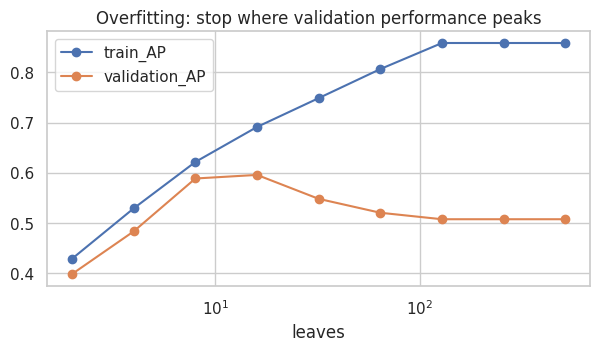

best number of leaves on validation: 16


cost-complexity PRUNING (grow, then prune): validation AP by alpha -> {np.float64(0.0): 0.493, np.float64(3e-06): 0.493, np.float64(4e-06): 0.508, np.float64(5e-06): 0.509, np.float64(8e-06): 0.529, np.float64(1.3e-05): 0.55, np.float64(1.8e-05): 0.551, np.float64(1.9e-05): 0.57}


In [9]:
# stopping decision: training vs VALIDATION performance as the tree grows (validation = last 55 days of the training period)
fit_i, val_i = trn.day < 200, trn.day >= 200
rows = []
for L in [2, 4, 8, 16, 32, 64, 128, 256, 512]:
    t = DecisionTreeClassifier(max_leaf_nodes=L, min_samples_leaf=5, random_state=0).fit(Xtr[fit_i], ytr[fit_i])
    rows.append(dict(leaves=L, train_AP=average_precision_score(ytr[fit_i], t.predict_proba(Xtr[fit_i])[:, 1]), validation_AP=average_precision_score(ytr[val_i], t.predict_proba(Xtr[val_i])[:, 1])))
vc = pd.DataFrame(rows).set_index("leaves"); vc.plot(logx=True, marker="o", figsize=(7, 3.3), title="Overfitting: stop where validation performance peaks"); plt.show()
best_L = int(vc.validation_AP.idxmax()); print("best number of leaves on validation:", best_L)
path = DecisionTreeClassifier(min_samples_leaf=5, random_state=0).cost_complexity_pruning_path(Xtr[fit_i], ytr[fit_i]); alphas = path.ccp_alphas[:: max(1, len(path.ccp_alphas) // 12)]
pr = {round(a, 6): average_precision_score(ytr[val_i], DecisionTreeClassifier(min_samples_leaf=5, ccp_alpha=a, random_state=0).fit(Xtr[fit_i], ytr[fit_i]).predict_proba(Xtr[val_i])[:, 1]) for a in alphas}
print("cost-complexity PRUNING (grow, then prune): validation AP by alpha ->", {k: round(v, 3) for k, v in list(pr.items())[:8]})

In [10]:
tree = DecisionTreeClassifier(max_leaf_nodes=best_L, min_samples_leaf=20, random_state=0).fit(Xtr, ytr)
print(f"test AUC {roc_auc_score(yte, tree.predict_proba(Xte)[:, 1]):.3f}, AP {average_precision_score(yte, tree.predict_proba(Xte)[:, 1]):.3f}")
# properties: monotone-transform invariance, outlier robustness, missing values
Xl = Xtr.copy(); Xl["log_amt"] = np.expm1(Xl.log_amt.clip(upper=10)); t2 = DecisionTreeClassifier(max_depth=4, random_state=0)
p1 = DecisionTreeClassifier(max_depth=4, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]; p2 = t2.fit(Xl, ytr).predict_proba(pd.DataFrame({**Xte, "log_amt": np.expm1(Xte.log_amt.clip(upper=10))}))[:, 1]
print("monotone transform of a feature (log -> exp): predictions identical ->", np.allclose(p1, p2))
Xm = Xtr.copy(); Xm = Xm.mask(rng.random(Xm.shape) < 0.05); Xte_m = Xte.mask(rng.random(Xte.shape) < 0.05)
print("with 5% missing values the tree still trains/scores (native NaN support): AUC", round(roc_auc_score(yte, DecisionTreeClassifier(max_depth=5, random_state=0).fit(Xm, ytr).predict_proba(Xte_m)[:, 1]), 3))
# instability: retrain on 5 bootstrap resamples -> different root splits
roots = []
for s in range(5):
    i = np.random.default_rng(s).integers(0, len(Xtr), len(Xtr)); t = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr.iloc[i], ytr[i]); roots.append((F[t.tree_.feature[0]], round(t.tree_.threshold[0], 2)))
print("root split on 5 bootstrap samples:", roots)

test AUC 0.859, AP 0.636


monotone transform of a feature (log -> exp): predictions identical -> True


with 5% missing values the tree still trains/scores (native NaN support): AUC 0.871


root split on 5 bootstrap samples: [('n_prev_1h', np.float64(1.5)), ('n_prev_1h', np.float64(1.5)), ('n_prev_1h', np.float64(1.5)), ('n_prev_1h', np.float64(1.5)), ('n_prev_1h', np.float64(1.5))]


In [11]:
# rules for a rule engine: every leaf = an if-then rule with support and precision
def tree_rules(t, names, X, y, min_n=30):
    T = t.tree_; leaf_of = t.apply(X.values if hasattr(X, "values") else X); out = []
    def walk(node, conds):
        if T.children_left[node] == -1:
            m = leaf_of == node; 
            if m.sum() >= min_n: out.append(dict(rule=" AND ".join(conds) or "TRUE", n=int(m.sum()), frauds=int(y[m].sum()), precision=y[m].mean()))
            return
        n_, thr = names[T.feature[node]], T.threshold[node]; walk(T.children_left[node], conds + [f"{n_} <= {thr:.2f}"]); walk(T.children_right[node], conds + [f"{n_} > {thr:.2f}"])
    walk(0, []); return pd.DataFrame(out).sort_values("precision", ascending=False)
rt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=0).fit(Xtr, ytr); rules = tree_rules(rt, F, Xtr, ytr, 30); pd.set_option("display.max_colwidth", 120); display(rules.head(5))
# regression tree: leaf = mean of the continuous target (log fraud amount)
rtree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, random_state=0).fit(fr_tr[Xf], fr_tr.log_amt); print(export_text(rtree, feature_names=Xf)[:700]); print("regression tree test R2:", round(r2_score(fr_te.log_amt, rtree.predict(fr_te[Xf])), 3))

,rule,n,frauds,precision
7,n_prev_1h > 1.50 AND n_prev_1h > 2.50,77,77,1.0000
6,n_prev_1h > 1.50 AND n_prev_1h <= 2.50,31,28,0.9032
1,n_prev_1h <= 1.50 AND log_hrs_since_prev <= 0.12 AND log_amt > 4.40,32,20,0.6250
0,n_prev_1h <= 1.50 AND log_hrs_since_prev <= 0.12 AND log_amt <= 4.40,30,7,0.2333
4,n_prev_1h <= 1.50 AND log_hrs_since_prev > 0.12 AND new_device > 0.50 AND log_hrs_since_prev <= 1.93,90,19,0.2111


|--- log_hrs_since_prev <= 6.29
|   |--- log_hrs_since_prev <= 2.93
|   |   |--- hour <= 1.50
|   |   |   |--- value: [5.24]
|   |   |--- hour >  1.50
|   |   |   |--- value: [4.91]
|   |--- log_hrs_since_prev >  2.93
|   |   |--- hour <= 9.50
|   |   |   |--- value: [4.99]
|   |   |--- hour >  9.50
|   |   |   |--- value: [5.70]
|--- log_hrs_since_prev >  6.29
|   |--- value: [4.71]

regression tree test R2: -0.06


## 6 · Neural networks
**Basic concepts.** Inspired by neurons: inputs → **hidden neurons** (weighted sum + bias, then a non-linear **activation**: logistic, tanh, linear) → output. A single hidden layer with enough neurons is a **universal approximator**; the model is a flexible non-linear function of the inputs. **Weight learning:** minimise an error function (cross-entropy / squared error) by **gradient descent with back-propagation**; use a **validation set** to stop training before overfitting ("training steps" curve); results depend on random initial weights. **Opening the black box:** (i) **variable selection** via weights/sensitivity, (ii) **rule extraction** (*decompositional* — from the neurons; *pedagogical* — fit a tree/rules to the network's predictions), (iii) **two-stage models** (simple interpretable model + NN on its residual).

XOR accuracy - logistic regression: 0.5


XOR accuracy - MLP from scratch (6 tanh neurons): 1.0


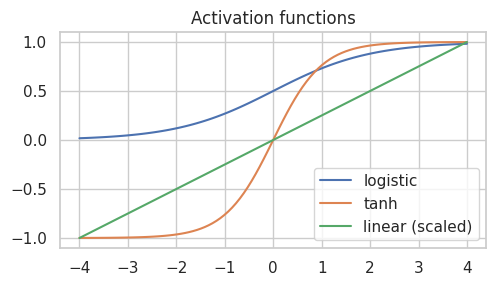

In [12]:
class MLP:
    '''One hidden layer (tanh), sigmoid output, trained by full-batch gradient descent with back-propagation.'''
    def __init__(self, d, h=8, seed=0): r = np.random.default_rng(seed); self.W1 = r.normal(0, .3, (d, h)); self.b1 = np.zeros(h); self.W2 = r.normal(0, .3, (h, 1)); self.b2 = np.zeros(1)
    def forward(self, X): self.A = np.tanh(X @ self.W1 + self.b1); return (1 / (1 + np.exp(-(self.A @ self.W2 + self.b2)))).ravel()
    def fit(self, X, y, Xv=None, yv=None, epochs=400, lr=0.5, w_pos=1.0, verbose=False):
        w = np.where(y == 1, w_pos, 1.0); hist = []
        for ep in range(epochs):
            p = self.forward(X); e = ((p - y) * w / w.sum())[:, None]                       # dLoss/dz for cross-entropy + sigmoid
            dW2 = self.A.T @ e; db2 = e.sum(0); dA = e @ self.W2.T * (1 - self.A ** 2); dW1 = X.T @ dA; db1 = dA.sum(0)
            self.W2 -= lr * dW2; self.b2 -= lr * db2; self.W1 -= lr * dW1; self.b1 -= lr * db1
            if Xv is not None and ep % 5 == 0:
                pv = np.clip(self.forward(Xv), 1e-9, 1 - 1e-9); hist.append((ep, -np.mean(np.r_[np.log(p[y == 1] + 1e-9), np.log(1 - p[y == 0] + 1e-9)]), -np.mean(np.r_[np.log(pv[yv == 1]), np.log(1 - pv[yv == 0])])))
        return pd.DataFrame(hist, columns=["epoch", "train_loss", "val_loss"])
    def predict_proba(self, X): return self.forward(X)
# XOR: no linear model can solve it, one hidden layer can
Xx = np.array([[0, 0], [0, 1], [1, 0], [1, 1]] * 25, float) + rng.normal(0, .05, (100, 2)); yx = (np.array([0, 1, 1, 0] * 25)).astype(float)
print("XOR accuracy - logistic regression:", round(LogisticRegression().fit(Xx, yx).score(Xx, yx), 2))
m_x = MLP(2, 6, seed=1); m_x.fit(Xx, yx, epochs=6000, lr=1.0); print("XOR accuracy - MLP from scratch (6 tanh neurons):", round(((m_x.predict_proba(Xx) > .5) == yx).mean(), 2))
z = np.linspace(-4, 4, 100); plt.figure(figsize=(5.5, 2.8)); plt.plot(z, 1 / (1 + np.exp(-z)), label="logistic"); plt.plot(z, np.tanh(z), label="tanh"); plt.plot(z, z / 4, label="linear (scaled)"); plt.legend(); plt.title("Activation functions"); plt.show()

best epoch by validation loss: 1495 of 1500


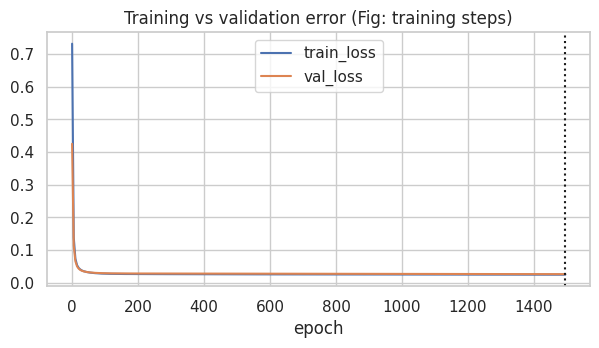

test AUC: from-scratch MLP 0.949 | sklearn MLP 0.944 | logistic 0.946


AUC over 5 random initialisations (results depend on the random starting weights): [0.949, 0.951, 0.95, 0.947, 0.947]


In [13]:
# weight learning on card fraud with a validation set (early stopping)
fit_m, val_m = (trn.day < 200).values, (trn.day >= 200).values
nn = MLP(len(F), 8, seed=0); h = nn.fit(Xtr_s[fit_m], ytr[fit_m].astype(float), Xtr_s[val_m], ytr[val_m].astype(float), epochs=1500, lr=1.0, w_pos=15)
best_ep = int(h.loc[h.val_loss.idxmin(), "epoch"]); print("best epoch by validation loss:", best_ep, "of 1500")
h.plot(x="epoch", figsize=(7, 3.3), title="Training vs validation error (Fig: training steps)"); plt.axvline(best_ep, c="k", ls=":"); plt.show()
nn = MLP(len(F), 8, seed=0); nn.fit(Xtr_s, ytr.astype(float), epochs=max(best_ep, 20), lr=1.0, w_pos=15)
p_nn = nn.predict_proba(Xte_s); p_sk = MLPClassifier(hidden_layer_sizes=(8,), max_iter=300, random_state=0).fit(Xtr_s, ytr).predict_proba(Xte_s)[:, 1]
print(f"test AUC: from-scratch MLP {roc_auc_score(yte, p_nn):.3f} | sklearn MLP {roc_auc_score(yte, p_sk):.3f} | logistic {roc_auc_score(yte, LogisticRegression(max_iter=2000).fit(Xtr_s, ytr).predict_proba(Xte_s)[:, 1]):.3f}")
seeds = []
for s in range(5): m_ = MLP(len(F), 8, seed=s); m_.fit(Xtr_s, ytr.astype(float), epochs=max(best_ep, 20), lr=1.0, w_pos=15); seeds.append(round(roc_auc_score(yte, m_.predict_proba(Xte_s)), 3))
print("AUC over 5 random initialisations (results depend on the random starting weights):", seeds)

In [14]:
# ---- opening the black box ----
imp_w = np.abs(nn.W1) @ np.abs(nn.W2).ravel(); imp_perm = permutation_importance(MLPClassifier(hidden_layer_sizes=(8,), max_iter=300, random_state=0).fit(Xtr_s, ytr), Xte_s[:15000], yte[:15000], scoring="average_precision", n_repeats=3, random_state=0)
print(pd.DataFrame({"weight-based (sum |w1|.|w2|)": imp_w / imp_w.sum(), "permutation importance (AP drop)": imp_perm.importances_mean}, index=F).round(3).sort_values("permutation importance (AP drop)", ascending=False))
# pedagogical rule extraction: tree trained on the network's own predictions (fidelity = agreement with the NN decision)
p_tr = nn.predict_proba(Xtr_s); cut = np.quantile(p_tr, 0.99); y_nn = (p_tr >= cut).astype(int)
rule_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=0).fit(Xtr, y_nn); print(f"rule-extraction tree: fidelity to NN = {rule_tree.score(Xtr, y_nn):.3f}"); print(export_text(rule_tree, feature_names=F))
# two-stage model: linear model first, small NN predicts its residual
lin = LogisticRegression(max_iter=2000).fit(Xtr_s, ytr); r_tr = ytr - lin.predict_proba(Xtr_s)[:, 1]
stage2 = MLPRegressor(hidden_layer_sizes=(6,), max_iter=200, random_state=0).fit(Xtr_s, r_tr); p2 = np.clip(lin.predict_proba(Xte_s)[:, 1] + stage2.predict(Xte_s), 0, 1)
print(f"two-stage (logistic + NN on residual) test AUC {roc_auc_score(yte, p2):.3f} vs logistic alone {roc_auc_score(yte, lin.predict_proba(Xte_s)[:, 1]):.3f} - the linear part remains explainable")

                    weight-based (sum |w1|.|w2|)  \
n_prev_1h                                 0.0800   
new_device                                0.0780   
n_prev_24h                                0.1640   
foreign                                   0.0960   
night                                     0.1070   
log_amt                                   0.1050   
log_hrs_since_prev                        0.1580   
hour                                      0.0800   
amt_z                                     0.1320   

                    permutation importance (AP drop)  
n_prev_1h                                     0.4300  
new_device                                    0.1530  
n_prev_24h                                    0.1060  
foreign                                       0.0830  
night                                         0.0530  
log_amt                                       0.0200  
log_hrs_since_prev                            0.0180  
hour                                   

two-stage (logistic + NN on residual) test AUC 0.917 vs logistic alone 0.946 - the linear part remains explainable


## 7 · Support vector machines
**Linear programming.** A linear classifier w·x + b can be found by *linear programming*: minimise the sum of errors ξᵢ subject to yᵢ(w·xᵢ + b) ≥ 1 − ξᵢ, ξᵢ ≥ 0. **Linear separable case.** Among all separating hyperplanes choose the one with the **maximum margin** (distance 2/‖w‖ between the two parallel supporting planes) → a **convex quadratic programme**; only the **support vectors** define the solution. **Nonseparable case.** Add **slack variables** ξ: min ½‖w‖² + C Σξᵢ; C trades margin width vs training errors. **Nonlinear SVM.** Map inputs to a high-dimensional space φ(x) and use a **kernel** K(x,z) = φ(x)·φ(z) (polynomial, RBF, …) — the *kernel trick*. **SVM for regression (SVR).** ε-insensitive loss: errors inside an ε-tube cost nothing. **Opening the black box:** rule extraction, two-stage models — as for neural networks.

LP classifier: w = [0.58  0.566] b = -1.598 | training accuracy 1.0


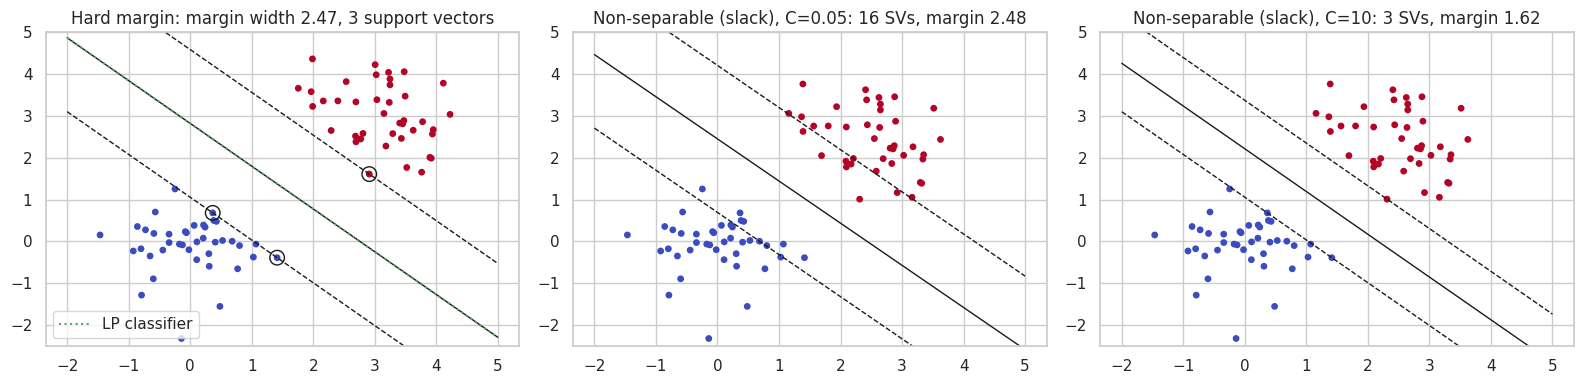

In [15]:
Xb = np.r_[rng.normal([0, 0], .7, (40, 2)), rng.normal([3, 3], .7, (40, 2))]; yb = np.r_[-np.ones(40), np.ones(40)]
def lp_classifier(X, y, lam=0.01):
    n, d = X.shape                                                       # variables: w+ (d), w- (d), b+, b-, xi (n)  ;  minimise sum(xi) + lam*||w||_1
    c = np.r_[lam * np.ones(2 * d), 0, 0, np.ones(n)]; A = -np.c_[y[:, None] * X, -y[:, None] * X, y, -y, np.eye(n)]; res = optimize.linprog(c, A_ub=A, b_ub=-np.ones(n), bounds=[(0, None)] * (2 * d + 2 + n))
    w = res.x[:d] - res.x[d:2 * d]; b = res.x[2 * d] - res.x[2 * d + 1]; return w, b
w_lp, b_lp = lp_classifier(Xb, yb); print("LP classifier: w =", w_lp.round(3), "b =", round(b_lp, 3), "| training accuracy", (np.sign(Xb @ w_lp + b_lp) == yb).mean())
svm = SVC(kernel="linear", C=1e6).fit(Xb, yb); w_s, b_s = svm.coef_[0], svm.intercept_[0]; margin = 2 / np.linalg.norm(w_s)
fig, ax = plt.subplots(1, 3, figsize=(16, 4)); ax[0].scatter(*Xb.T, c=yb, cmap="coolwarm", s=15); gx = np.linspace(-2, 5, 50)
for off, ls in [(0, "-"), (1, "--"), (-1, "--")]: ax[0].plot(gx, (off - b_s - w_s[0] * gx) / w_s[1], "k" + ls, lw=1)
ax[0].scatter(*svm.support_vectors_.T, s=110, facecolors="none", edgecolors="k"); ax[0].plot(gx, (-b_lp - w_lp[0] * gx) / w_lp[1], "g:", label="LP classifier"); ax[0].legend(); ax[0].set(ylim=(-2.5, 5), title=f"Hard margin: margin width {margin:.2f}, {len(svm.support_vectors_)} support vectors")
Xn2 = np.r_[Xb[:40] + 0, Xb[40:] - 0.6]; 
for a_, C in zip(ax[1:], [0.05, 10]):
    s2 = SVC(kernel="linear", C=C).fit(Xn2, yb); w2, b2 = s2.coef_[0], s2.intercept_[0]; a_.scatter(*Xn2.T, c=yb, cmap="coolwarm", s=15)
    for off, ls in [(0, "-"), (1, "--"), (-1, "--")]: a_.plot(gx, (off - b2 - w2[0] * gx) / w2[1], "k" + ls, lw=1)
    a_.set(ylim=(-2.5, 5), title=f"Non-separable (slack), C={C}: {len(s2.support_vectors_)} SVs, margin {2 / np.linalg.norm(w2):.2f}")
plt.tight_layout(); plt.show()

K(x,z) = (x.z)^2 = 1.0 | phi(x).phi(z) = 1.0


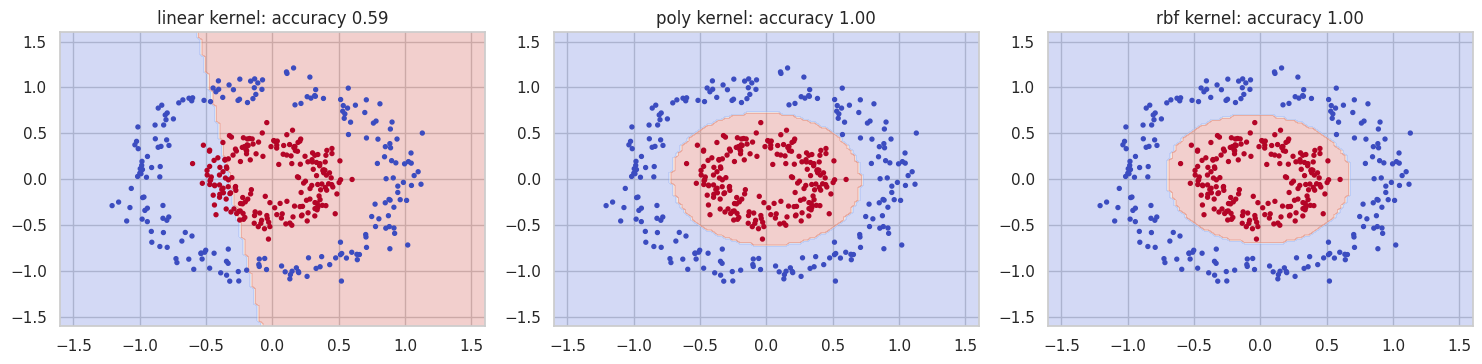

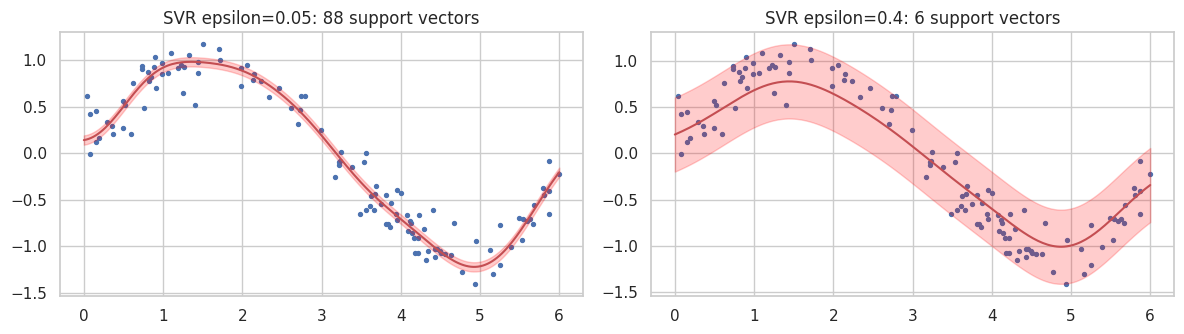

In [16]:
# kernel trick: quadratic kernel (x.z)^2 equals the dot product in the explicit feature space phi(x) = (x1^2, sqrt2*x1*x2, x2^2)
phi = lambda x: np.array([x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2]); a_, b_ = np.array([1.0, 2.0]), np.array([3.0, -1.0]); print("K(x,z) = (x.z)^2 =", (a_ @ b_) ** 2, "| phi(x).phi(z) =", round(float(phi(a_) @ phi(b_)), 6))
from sklearn.datasets import make_circles
Xc, yc = make_circles(400, noise=.1, factor=.4, random_state=0); fig, ax = plt.subplots(1, 3, figsize=(15, 3.8)); gx, gy = np.meshgrid(np.linspace(-1.6, 1.6, 120), np.linspace(-1.6, 1.6, 120))
for a_, (kern, kw) in zip(ax, [("linear", {}), ("poly", dict(degree=2)), ("rbf", dict(gamma=1.0))]):
    s = SVC(kernel=kern, C=1, **kw).fit(Xc, yc); a_.contourf(gx, gy, s.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape), alpha=.25, cmap="coolwarm"); a_.scatter(*Xc.T, c=yc, cmap="coolwarm", s=8); a_.set_title(f"{kern} kernel: accuracy {s.score(Xc, yc):.2f}")
plt.tight_layout(); plt.show()
# SVR: epsilon-insensitive tube
xs = np.sort(rng.uniform(0, 6, 120))[:, None]; ys = np.sin(xs).ravel() + rng.normal(0, .2, 120); fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a_, eps in zip(ax, [0.05, 0.4]):
    r = SVR(kernel="rbf", C=5, epsilon=eps, gamma=1).fit(xs, ys); g = np.linspace(0, 6, 200)[:, None]; pr = r.predict(g); a_.scatter(xs, ys, s=8); a_.plot(g, pr, "r"); a_.fill_between(g.ravel(), pr - eps, pr + eps, alpha=.2, color="red"); a_.set_title(f"SVR epsilon={eps}: {len(r.support_)} support vectors")
plt.tight_layout(); plt.show()

In [17]:
# SVM on the card-fraud data (scaling is essential): train on all frauds + a sample of genuine transactions, balanced class weights
sub = np.r_[np.flatnonzero(ytr == 1), rng.choice(np.flatnonzero(ytr == 0), 6000, replace=False)]
t0 = time.time(); svm_c = SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced").fit(Xtr_s[sub], ytr[sub]); s_svm = svm_c.decision_function(Xte_s)
print(f"RBF-SVM test AUC {roc_auc_score(yte, s_svm):.3f}, AP {average_precision_score(yte, s_svm):.3f} | {len(svm_c.support_)} support vectors | {time.time() - t0:.1f}s")
# opening the SVM black box: pedagogical rule extraction + permutation importance
tr_dec = (svm_c.decision_function(Xtr_s[sub]) > 0).astype(int); rule_svm = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xtr.iloc[sub], tr_dec)
print(f"rule tree fidelity to SVM: {rule_svm.score(Xtr.iloc[sub], tr_dec):.3f}"); print(export_text(rule_svm, feature_names=F)[:600])

RBF-SVM test AUC 0.928, AP 0.131 | 1181 support vectors | 1.0s
rule tree fidelity to SVM: 0.974
|--- new_device <= 0.50
|   |--- log_hrs_since_prev <= 1.12
|   |   |--- log_hrs_since_prev <= 0.71
|   |   |   |--- class: 1
|   |   |--- log_hrs_since_prev >  0.71
|   |   |   |--- class: 1
|   |--- log_hrs_since_prev >  1.12
|   |   |--- n_prev_24h <= 1.50
|   |   |   |--- class: 0
|   |   |--- n_prev_24h >  1.50
|   |   |   |--- class: 1
|--- new_device >  0.50
|   |--- log_amt <= 4.14
|   |   |--- foreign <= 0.50
|   |   |   |--- class: 0
|   |   |--- foreign >  0.50
|   |   |   |--- class: 1
|   |--- log_amt >  4.14
|   |   |--- log_amt <= 4.49
|   |   |   |--- class: 1
|   |   |--- log_


## 8 · Ensemble methods
Estimate **several models and combine their predictions** (vote/average). *Why it works:* averaging reduces **variance** of unstable learners such as trees.
* **Bagging** (bootstrap aggregating): train each model on a **bootstrap sample**; average.
* **Boosting**: build models **sequentially**, each **re-weighting** the observations the previous ones misclassified (AdaBoost); gradient boosting fits the residual errors.
* **Random forests**: bagging of trees **plus random subset of variables at each split** (decorrelates the trees); out-of-bag estimate of error; variable importance.
* **Evaluating ensembles:** compare against single models on unseen data *and* look at **stability**; the price is **loss of interpretability** and operational cost.

In [18]:
# Bagging by hand + variance reduction: repeat on different training subsamples
sub_pos = np.flatnonzero(ytr == 1); sub_neg = np.flatnonzero(ytr == 0)
def subsample(seed): r = np.random.default_rng(seed); return np.r_[sub_pos, r.choice(sub_neg, 12000, replace=False)]
def bag_fit_predict(idx, B=40, seed=0):
    r = np.random.default_rng(seed); ps = []
    for b in range(B): i = r.choice(idx, len(idx), replace=True); ps.append(DecisionTreeClassifier(min_samples_leaf=5, random_state=b).fit(Xtr.iloc[i], ytr[i]).predict_proba(Xte)[:, 1])
    return np.mean(ps, 0)
res = {"single tree": [], "bagging (40 trees, by hand)": [], "random forest (200)": []}
for s in range(8):
    idx = subsample(s)
    res["single tree"].append(roc_auc_score(yte, DecisionTreeClassifier(min_samples_leaf=5, random_state=0).fit(Xtr.iloc[idx], ytr[idx]).predict_proba(Xte)[:, 1]))
    res["bagging (40 trees, by hand)"].append(roc_auc_score(yte, bag_fit_predict(idx, 40, s)))
    res["random forest (200)"].append(roc_auc_score(yte, RandomForestClassifier(200, min_samples_leaf=5, max_features="sqrt", n_jobs=-1, random_state=s).fit(Xtr.iloc[idx], ytr[idx]).predict_proba(Xte)[:, 1]))
display(pd.DataFrame(res).agg(["mean", "std"]).T.rename(columns={"mean": "mean test AUC", "std": "sd over 8 training samples"}))

,mean test AUC,sd over 8 training samples
single tree,0.8586,0.0079
"bagging (40 trees, by hand)",0.9124,0.0042
random forest (200),0.9420,0.0035


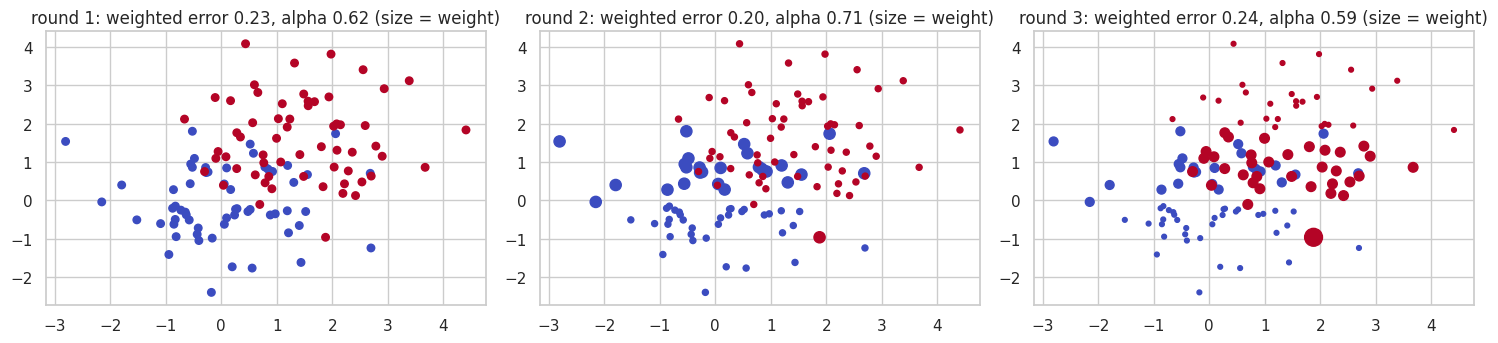

boosted ensemble accuracy after 6 stumps: 0.8833333333333333 | single stump: 0.775


In [19]:
# AdaBoost from scratch on a toy problem: watch the observation weights change
Xa = np.r_[rng.normal([0, 0], 1, (60, 2)), rng.normal([1.5, 1.5], 1, (60, 2))]; ya = np.r_[-np.ones(60), np.ones(60)]
w = np.ones(len(Xa)) / len(Xa); stumps = []; fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for m in range(6):
    st = DecisionTreeClassifier(max_depth=1).fit(Xa, ya, sample_weight=w); pr_ = st.predict(Xa); err = w[pr_ != ya].sum(); alpha = 0.5 * np.log((1 - err) / max(err, 1e-9))
    stumps.append((alpha, st))
    if m < 3: ax[m].scatter(*Xa.T, c=ya, cmap="coolwarm", s=w * 3500); ax[m].set_title(f"round {m + 1}: weighted error {err:.2f}, alpha {alpha:.2f} (size = weight)")
    w = w * np.exp(-alpha * ya * pr_); w /= w.sum()
plt.tight_layout(); plt.show()
H = np.sign(sum(a * s.predict(Xa) for a, s in stumps)); print("boosted ensemble accuracy after 6 stumps:", (H == ya).mean(), "| single stump:", (stumps[0][1].predict(Xa) == ya).mean())

,AUC,AP
logistic,0.9458,0.7084
single tree,0.8950,0.6331
bagging (sklearn),0.9188,0.6952
random forest,0.9435,0.7046
AdaBoost,0.9437,0.7054
gradient boosting,0.9502,0.6240


random-forest OUT-OF-BAG accuracy estimate: 0.9915


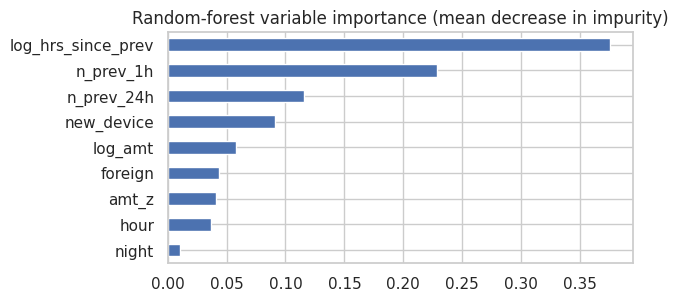

In [20]:
idx = subsample(0); models = {"logistic": LogisticRegression(max_iter=2000), "single tree": DecisionTreeClassifier(min_samples_leaf=20, max_depth=8, random_state=0),
        "bagging (sklearn)": BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=5), n_estimators=100, random_state=0, n_jobs=-1),
        "random forest": RandomForestClassifier(300, min_samples_leaf=5, oob_score=True, n_jobs=-1, random_state=0),
        "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=150, random_state=0),
        "gradient boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.7, random_state=0)}
rows = {}
for nm, m in models.items():
    Xa_, Xb_ = (Xtr_s[idx], Xte_s) if nm == "logistic" else (Xtr.iloc[idx], Xte); m.fit(Xa_, ytr[idx]); p = m.predict_proba(Xb_)[:, 1]; rows[nm] = dict(AUC=roc_auc_score(yte, p), AP=average_precision_score(yte, p))
display(pd.DataFrame(rows).T); rf = models["random forest"]; print("random-forest OUT-OF-BAG accuracy estimate:", round(rf.oob_score_, 4))
pd.Series(rf.feature_importances_, index=F).sort_values().plot.barh(figsize=(6, 3), title="Random-forest variable importance (mean decrease in impurity)"); plt.show()

## 9 · Multiclass classification techniques
Sometimes the target has **more than two classes** — e.g. the **type** of fraud/laundering. Extensions: **multinomial (softmax) logistic regression** P(class k|x) = e^{z_k} / Σⱼ e^{z_j}; **multiclass trees** (leaves carry class distributions); **multiclass NN** (softmax output layer, one neuron per class); **multiclass SVM** by decomposition — **one-versus-rest** or **one-versus-one**. Evaluation: confusion matrix and **the average of the two-class AUCs over all m(m−1)/2 class pairs**. Lab target: the **typology** of the suspicious customers.

In [21]:
ty = feat[feat.is_launderer == 1].reset_index(drop=True); XM = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "sub_floor_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "cash_share_credits", "log_n_txn", "log_amt_wire_in", "night_share", "n_cash_dep"]
Xm_, ym_ = ty[XM].values, ty.typology.values; classes = np.unique(ym_); print(pd.Series(ym_).value_counts().to_dict())
skf = StratifiedKFold(5, shuffle=True, random_state=0)
soft = LogisticRegression(max_iter=5000, C=1.0).fit(StandardScaler().fit_transform(Xm_), ym_); Zs_ = StandardScaler().fit(Xm_).transform(Xm_); zk = Zs_ @ soft.coef_.T + soft.intercept_
manual = np.exp(zk) / np.exp(zk).sum(1, keepdims=True); print("softmax by hand == predict_proba:", np.allclose(manual, LogisticRegression(max_iter=5000).fit(Zs_, ym_).predict_proba(Zs_), atol=1e-3) if False else np.allclose(manual.sum(1), 1))
pipe = lambda est: __import__("sklearn.pipeline", fromlist=["make_pipeline"]).make_pipeline(StandardScaler(), est)
models = {"multinomial logistic": pipe(LogisticRegression(max_iter=5000)), "logistic one-vs-rest": pipe(OneVsRestClassifier(LogisticRegression(max_iter=5000))), "multiclass tree": DecisionTreeClassifier(max_depth=4, random_state=0),
          "random forest": RandomForestClassifier(300, random_state=0), "multiclass NN (softmax)": pipe(MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=0)), "SVM one-vs-one": pipe(SVC(probability=True, random_state=0)), "SVM one-vs-rest": pipe(OneVsRestClassifier(SVC(probability=True, random_state=0)))}
def pairwise_auc(y, P, classes):
    '''average over class pairs of [AUC(i|j) + AUC(j|i)] / 2  (Hand & Till)'''
    out = []
    for a, b in itertools.combinations(range(len(classes)), 2):
        m = np.isin(y, [classes[a], classes[b]]); yy = (y[m] == classes[a]).astype(int); out.append((roc_auc_score(yy, P[m, a]) + roc_auc_score(1 - yy, P[m, b])) / 2)
    return np.mean(out)
rows = {}
for nm, m in models.items():
    P = cross_val_predict(m, Xm_, ym_, cv=skf, method="predict_proba"); pred = np.array(sorted(classes))[P.argmax(1)]
    rows[nm] = dict(accuracy=accuracy_score(ym_, pred), macro_F1=f1_score(ym_, pred, average="macro"), pairwise_AUC=pairwise_auc(ym_, P, sorted(classes)), sklearn_ovo_AUC=roc_auc_score(ym_, P, multi_class="ovo", labels=sorted(classes)))
display(pd.DataFrame(rows).T); print("(my pairwise AUC equals sklearn's macro one-vs-one AUC; chance = 0.5, majority-class accuracy =", round(pd.Series(ym_).value_counts(normalize=True).max(), 2), ")")
P = cross_val_predict(models["random forest"], Xm_, ym_, cv=skf); print(pd.DataFrame(confusion_matrix(ym_, P, labels=sorted(classes)), index=[f"true {c}" for c in sorted(classes)], columns=sorted(classes)))

{'structuring': 47, 'mule_ring': 23, 'smurfing_low': 20, 'pass_through': 19, 'commingling': 14}
softmax by hand == predict_proba: True


,accuracy,macro_F1,pairwise_AUC,sklearn_ovo_AUC
multinomial logistic,0.9512,0.9270,0.9926,0.9926
logistic one-vs-rest,0.9431,0.9122,0.9937,0.9937
multiclass tree,0.9268,0.9074,0.9546,0.9546
random forest,0.9512,0.9371,0.9906,0.9906
multiclass NN (softmax),0.9024,0.8665,0.9836,0.9836
SVM one-vs-one,0.9350,0.9110,0.9821,0.9821
SVM one-vs-rest,0.9431,0.9226,0.9760,0.9760


(my pairwise AUC equals sklearn's macro one-vs-one AUC; chance = 0.5, majority-class accuracy = 0.38 )


                   commingling  mule_ring  pass_through  smurfing_low  \
true commingling            10          1             0             1   
true mule_ring               0         21             1             0   
true pass_through            0          0            19             0   
true smurfing_low            0          0             0            20   
true structuring             0          0             0             0   

                   structuring  
true commingling             2  
true mule_ring               1  
true pass_through            0  
true smurfing_low            0  
true structuring            47  


## 10 · Evaluating predictive models
### 10.1 Splitting up the data set
* **Hold-out** (train/test, often with a validation set) — simple; result depends on the split. **Stratified** to keep the class ratio.
* **k-fold cross-validation**, **leave-one-out** (k = n), **bootstrapping** (train on a bootstrap sample, test on the out-of-bag; the .632 estimator combines it with the training error).
* **Out-of-time / out-of-sample** samples — the honest choice in fraud because behaviour drifts.

In [22]:
Xcu, ycu = StandardScaler().fit_transform(feat[["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "cash_share_credits", "log_n_txn"]]), feat.is_launderer.values
lr = LogisticRegression(max_iter=3000); res = {}
res["hold-out (30%) x 30 random splits"] = [roc_auc_score(ycu[te], lr.fit(Xcu[tr], ycu[tr]).predict_proba(Xcu[te])[:, 1]) for tr, te in [train_test_split(np.arange(len(ycu)), test_size=.3, stratify=ycu, random_state=s) for s in range(30)]]
res["10-fold CV x 3 repeats"] = [cross_val_score(lr, Xcu, ycu, cv=StratifiedKFold(10, shuffle=True, random_state=s), scoring="roc_auc").mean() for s in range(3)]
def boot_auc(s):
    r = np.random.default_rng(s); i = r.integers(0, len(ycu), len(ycu)); oob = np.setdiff1d(np.arange(len(ycu)), i); m = lr.fit(Xcu[i], ycu[i])
    return 0.368 * roc_auc_score(ycu[i], m.predict_proba(Xcu[i])[:, 1]) + 0.632 * roc_auc_score(ycu[oob], m.predict_proba(Xcu[oob])[:, 1])       # .632 bootstrap estimator
res[".632 bootstrap x 30"] = [boot_auc(s) for s in range(30)]
res["LOO (500-customer subset, pooled predictions)"] = [roc_auc_score(ycu[:500] if ycu[:500].sum() > 0 else ycu[:500], cross_val_predict(lr, Xcu[:500], ycu[:500], cv=LeaveOneOut(), method="predict_proba")[:, 1])] if ycu[:500].sum() > 3 else [np.nan]
display(pd.DataFrame({k: dict(mean_AUC=np.mean(v), sd=np.std(v), n=len(v)) for k, v in res.items()}).T)
print("the spread of hold-out estimates is the price of a single split; CV and bootstrap use all the data. For card fraud we used an OUT-OF-TIME split (train < day 255, test >= day 255).")

,mean_AUC,sd,n
hold-out (30%) x 30 random splits,0.9589,0.0114,30.0000
10-fold CV x 3 repeats,0.9619,0.0010,3.0000
.632 bootstrap x 30,0.9607,0.0062,30.0000
"LOO (500-customer subset, pooled predictions)",0.8849,0.0000,1.0000


the spread of hold-out estimates is the price of a single split; CV and bootstrap use all the data. For card fraud we used an OUT-OF-TIME split (train < day 255, test >= day 255).


### 10.2 Performance measures for classification
Given a score and a cut-off: **confusion matrix** → accuracy, **sensitivity (recall, hit rate)** = TP/(TP+FN), **specificity** = TN/(TN+FP), precision, F1. Threshold-free: **ROC curve** (sensitivity vs 1−specificity) and **AUC** (probability a random fraud outranks a random genuine case; = Mann–Whitney U/(n₁n₂)); **CAP curve** (cumulative accuracy profile: % of frauds caught vs % of population screened) with **accuracy ratio AR = 2·AUC − 1 (Gini)**; **lift** = precision in the top x % / base rate; **KS distance** = maximum distance between the cumulative score distributions of frauds and non-frauds; **Mahalanobis distance M = |μ_fraud − μ_genuine| / s** between the score distributions.

In [23]:
sc_ = LogisticRegression(max_iter=2000).fit(Xtr_s, ytr).predict_proba(Xte_s)[:, 1]; y_ = yte; n1, n0 = y_.sum(), (1 - y_).sum()
thr = np.quantile(sc_, 0.99); pred = (sc_ >= thr).astype(int); tn, fp, fn, tp = confusion_matrix(y_, pred).ravel()
print(pd.DataFrame([[tp, fn], [fp, tn]], index=["actual fraud", "actual genuine"], columns=["predicted fraud", "predicted genuine"]))
print(f"accuracy {(tp + tn) / len(y_):.4f} (a model saying 'never fraud' scores {1 - y_.mean():.4f}!) | sensitivity {tp / (tp + fn):.3f} | specificity {tn / (tn + fp):.4f} | precision {tp / (tp + fp):.3f} | F1 {2 * tp / (2 * tp + fp + fn):.3f}")
U = stats.mannwhitneyu(sc_[y_ == 1], sc_[y_ == 0]).statistic; auc = roc_auc_score(y_, sc_); print(f"AUC = {auc:.4f} | Mann-Whitney U/(n1 n0) = {U / (n1 * n0):.4f}")
order = np.argsort(-sc_); cap_x = np.arange(1, len(y_) + 1) / len(y_); cap_y = np.cumsum(y_[order]) / n1
AR = (np.trapezoid(cap_y, cap_x) - 0.5) / ((1 - n1 / len(y_) / 2) - 0.5); print(f"CAP accuracy ratio AR = {AR:.3f} | Gini = 2*AUC-1 = {2 * auc - 1:.3f}  (equal up to numerical integration)")
ks = stats.ks_2samp(sc_[y_ == 1], sc_[y_ == 0]).statistic; M = abs(sc_[y_ == 1].mean() - sc_[y_ == 0].mean()) / np.sqrt((n1 * sc_[y_ == 1].var(ddof=1) + n0 * sc_[y_ == 0].var(ddof=1)) / (n1 + n0)); print(f"KS distance = {ks:.3f} | Mahalanobis-type distance M = {M:.3f}")

                predicted fraud  predicted genuine
actual fraud                101                 39
actual genuine              154              25140
accuracy 0.9924 (a model saying 'never fraud' scores 0.9945!) | sensitivity 0.721 | specificity 0.9939 | precision 0.396 | F1 0.511
AUC = 0.9464 | Mann-Whitney U/(n1 n0) = 0.9464
CAP accuracy ratio AR = 0.893 | Gini = 2*AUC-1 = 0.893  (equal up to numerical integration)
KS distance = 0.794 | Mahalanobis-type distance M = 15.876


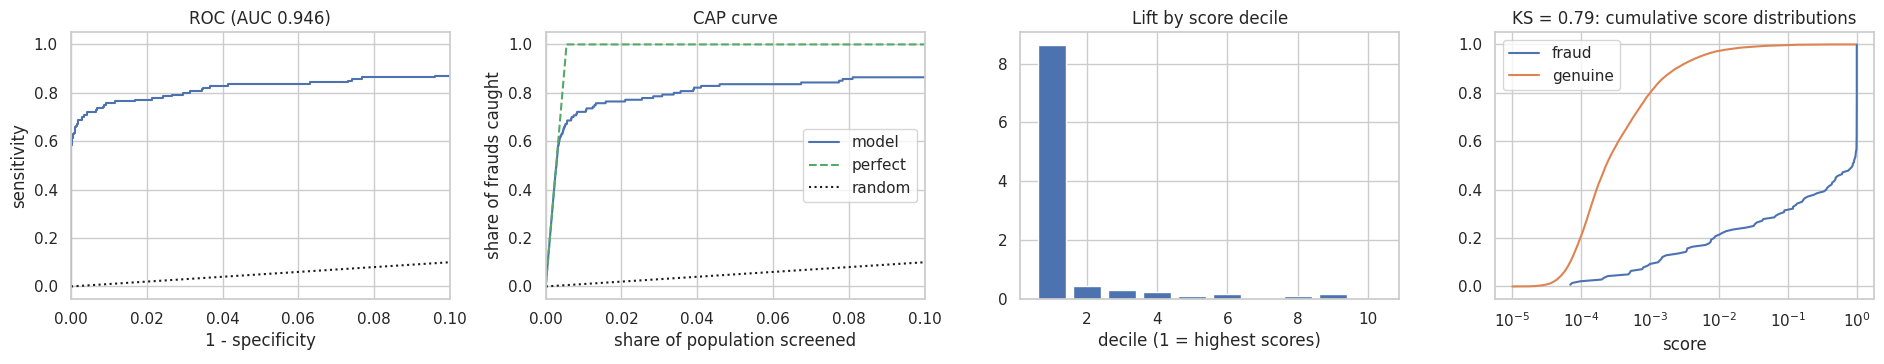

In [24]:
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8)); fpr, tpr, _ = roc_curve(y_, sc_); ax[0].plot(fpr, tpr); ax[0].plot([0, 1], [0, 1], "k:"); ax[0].set(title=f"ROC (AUC {auc:.3f})", xlabel="1 - specificity", ylabel="sensitivity", xlim=(0, 0.1))
ax[1].plot(cap_x, cap_y, label="model"); ax[1].plot([0, n1 / len(y_), 1], [0, 1, 1], "g--", label="perfect"); ax[1].plot([0, 1], [0, 1], "k:", label="random"); ax[1].set(title="CAP curve", xlabel="share of population screened", ylabel="share of frauds caught", xlim=(0, .1)); ax[1].legend()
d10 = pd.qcut(pd.Series(sc_).rank(method="first", ascending=False), 10, labels=False); lift = pd.Series(y_).groupby(d10.values).mean() / y_.mean(); ax[2].bar(lift.index + 1, lift.values); ax[2].set(title="Lift by score decile", xlabel="decile (1 = highest scores)")
for c_, lab_ in [(1, "fraud"), (0, "genuine")]: v = np.sort(sc_[y_ == c_]); ax[3].plot(v, np.arange(1, len(v) + 1) / len(v), label=lab_)
ax[3].set(title=f"KS = {ks:.2f}: cumulative score distributions", xscale="log", xlabel="score"); ax[3].legend(); plt.tight_layout(); plt.show()

### 10.3 Performance measures for regression models
**Scatter of predicted vs actual** and their **Pearson correlation**; **R² = 1 − Σ(yᵢ − ŷᵢ)² / Σ(yᵢ − ȳ)²** (improvement over predicting the mean; can be **negative on a test set**); **adjusted R²** = 1 − (n−1)/(n−p−1)·(1−R²); **MSE / RMSE / MAE** (error in target units).

### 10.4 Other performance measures
Statistical accuracy is one of several requirements (chapter 1, Table 1.4): **operational efficiency** (speed of scoring), **interpretability**, **economic cost / profit**, **stability**, **regulatory compliance**. Fraud metrics should weigh **amounts**, not only counts.

In [25]:
p_tr_ = ols.predict(sm.add_constant(fr_tr[Xf])); n_, p_ = len(fr_te), len(Xf); yt = fr_te.log_amt.values; yp = ols.predict(sm.add_constant(fr_te[Xf])).values
r2 = 1 - ((yt - yp) ** 2).sum() / ((yt - yt.mean()) ** 2).sum(); print(pd.Series({"Pearson corr": np.corrcoef(yp, yt)[0, 1], "R2 (test)": r2, "adjusted R2": 1 - (n_ - 1) / (n_ - p_ - 1) * (1 - r2), "MSE": mean_squared_error(yt, yp), "RMSE": np.sqrt(mean_squared_error(yt, yp)), "MAE": mean_absolute_error(yt, yp)}).round(3).to_string())
print("R2 of predicting the TRAINING mean for every test case (baseline):", round(1 - ((yt - fr_tr.log_amt.mean()) ** 2).sum() / ((yt - yt.mean()) ** 2).sum(), 3), "-> negative/near-zero R2 on test data is possible")
# an amount-weighted, cost-aware view (other measures): fraud VALUE caught at a review budget, and expected cost
amt = tst.amount_usd.values; budget = int(0.01 * len(y_)); top = np.argsort(-sc_)[:budget]
print(f"reviewing the top 1% ({budget} txns): catches {y_[top].sum() / y_.sum():.1%} of frauds but {(amt * y_)[top].sum() / (amt * y_).sum():.1%} of fraud VALUE; review cost at $3 each = ${3 * budget:,.0f}")

Pearson corr   -0.0240
R2 (test)      -0.0290
adjusted R2    -0.0840
MSE             0.8140
RMSE            0.9020
MAE             0.6850
R2 of predicting the TRAINING mean for every test case (baseline): -0.005 -> negative/near-zero R2 on test data is possible
reviewing the top 1% (254 txns): catches 72.1% of frauds but 81.8% of fraud VALUE; review cost at $3 each = $762


## 11 · Developing predictive models for **skewed** data sets
With ≈ 1 % (or far fewer) frauds, learners are flooded by non-fraud: a tree may find no useful split and classify everything as genuine — **99 % accuracy, zero fraudsters detected**. Ways to give the minority class more weight:

| technique | idea |
|---|---|
| **Varying the sample window** | longer prediction horizon, or sample each fraudster at several observation points |
| **Undersampling / oversampling** | drop non-fraud / replicate fraud — *on the training data only* |
| **SMOTE** | create synthetic fraud cases by interpolating between neighbours |
| **Likelihood approach** (Pluto & Tasche) | probability estimates with confidence bounds when (almost) **no** frauds are observed |
| **Adjusting posterior probabilities** | re-calibrate after re-sampling |
| **Cost-sensitive learning** | higher misclassification cost for missed frauds |

In [26]:
# ---- Varying the sample window ----
# (a) a longer window adds frauds: same model, training data taken from the last k months before the cut-off (test = later period)
rows = []
for months in [1, 2, 3, 5, 7, 8.5]:
    m_ = (trn.day >= 255 - int(months * 30)).values
    if ytr[m_].sum() < 3: continue
    lr_ = LogisticRegression(max_iter=2000).fit(Xtr_s[m_], ytr[m_]); rows.append(dict(window_months=months, rows=int(m_.sum()), frauds=int(ytr[m_].sum()), test_AUC=roc_auc_score(yte, lr_.predict_proba(Xte_s)[:, 1]), test_AP=average_precision_score(yte, lr_.predict_proba(Xte_s)[:, 1])))
display(pd.DataFrame(rows).set_index("window_months"))
print("trade-off from chapter 2: more data (robust) vs recent data (representative) - here fraud behaviour is stable, so longer windows help.")
# (b) 'sample every fraudster twice': shift the observation point so the SAME fraudster appears with slightly different (overlapping-window) features
def snapshot(t, back=90, ahead=60):
    past = cards[(cards.day > t - back) & (cards.day <= t)]; fut = cards[(cards.day > t) & (cards.day <= t + ahead)]
    g = past.groupby("customer_id").agg(n=("txn_id", "size"), mean_amt=("log_amt", "mean"), foreign=("foreign", "mean"), night=("night", "mean"), new_dev=("new_device", "mean"), burst=("n_prev_1h", "max"))
    g["y"] = g.index.isin(fut.loc[fut.is_fraud == 1, "customer_id"]).astype(int); return g
snaps = {t: snapshot(t) for t in (160, 200, 240)}
print(pd.DataFrame({f"observation point t={t}": dict(customers=len(g), positives=int(g.y.sum())) for t, g in snaps.items()}).T.assign(cumulative_positives=lambda d: d.positives.cumsum()))
print("customer-level 'will fraud occur in the next 60 days?' with 1, 2 or 3 observation points: the number of positive training rows grows (each fraudster appears with different feature values). In this synthetic lab victims are drawn at random, so the resulting models predict little - the mechanism, not the score, is the point.")

,rows,frauds,test_AUC,test_AP
window_months,,,,
1.0000,6927,15,0.9378,0.6934
2.0000,13961,43,0.9448,0.7005
3.0000,21004,70,0.9449,0.7085
5.0000,34707,136,0.9467,0.7081
7.0000,48677,196,0.9466,0.7112
8.5000,59029,243,0.9464,0.7107


trade-off from chapter 2: more data (robust) vs recent data (representative) - here fraud behaviour is stable, so longer windows help.


                         customers  positives  cumulative_positives
observation point t=160       3369         12                    12
observation point t=200       3353         14                    26
observation point t=240       3355         16                    42
customer-level 'will fraud occur in the next 60 days?' with 1, 2 or 3 observation points: the number of positive training rows grows (each fraudster appears with different feature values). In this synthetic lab victims are drawn at random, so the resulting models predict little - the mechanism, not the score, is the point.


In [27]:
# ---- Undersampling, oversampling, SMOTE  (training data only!) ----
def smote(X, n_new, k=5, seed=0):
    r = np.random.default_rng(seed); nn_ = NearestNeighbors(n_neighbors=k + 1).fit(X); nb = nn_.kneighbors(X)[1][:, 1:]; base = r.integers(0, len(X), n_new); pick = nb[base, r.integers(0, k, n_new)]
    return X[base] + r.random((n_new, 1)) * (X[pick] - X[base])                              # x + gap * (neighbour - x)
ex = smote.__wrapped__ if hasattr(smote, "__wrapped__") else None
a_, b_, gap = np.array([30, 1000.0]), np.array([62, 3200.0]), 0.75; print("book example:", a_ + gap * (b_ - a_), "(age 54, income 2,650)"); assert np.allclose(a_ + gap * (b_ - a_), [54, 2650])
pos = np.flatnonzero(ytr == 1); neg = np.flatnonzero(ytr == 0)
def make_train(kind, seed=0):
    r = np.random.default_rng(seed)
    if kind == "original": return Xtr_s, ytr
    if kind == "undersample 1:10": i = np.r_[pos, r.choice(neg, 10 * len(pos), replace=False)]; return Xtr_s[i], ytr[i]
    if kind == "oversample x20": i = np.r_[neg, r.choice(pos, 20 * len(pos), replace=True)]; return Xtr_s[i], ytr[i]
    if kind == "SMOTE (x10) + undersample": Xs_ = smote(Xtr_s[pos], 9 * len(pos), seed=seed); keep = r.choice(neg, 12 * len(pos) * 1, replace=False); return np.r_[Xtr_s[pos], Xs_, Xtr_s[keep]], np.r_[np.ones(10 * len(pos)), np.zeros(len(keep))].astype(int)
rows = {}
for kind in ["original", "undersample 1:10", "oversample x20", "SMOTE (x10) + undersample"]:
    Xk, yk = make_train(kind); m = RandomForestClassifier(200, min_samples_leaf=5, n_jobs=-1, random_state=0).fit(Xk, yk); p = m.predict_proba(Xte_s)[:, 1]
    rows[kind] = dict(train_fraud_share=yk.mean(), AUC=roc_auc_score(yte, p), AP=average_precision_score(yte, p), mean_predicted_p=p.mean())
display(pd.DataFrame(rows).T); print("true fraud rate in the test period:", round(yte.mean(), 4), "-> re-sampling inflates predicted probabilities (fixed below)")

book example: [  54. 2650.] (age 54, income 2,650)


,train_fraud_share,AUC,AP,mean_predicted_p
original,0.0041,0.9244,0.7016,0.0048
undersample 1:10,0.0909,0.9478,0.6999,0.0304
oversample x20,0.0764,0.9162,0.7021,0.0076
SMOTE (x10) + undersample,0.4545,0.9445,0.6601,0.0753


true fraud rate in the test period: 0.0055 -> re-sampling inflates predicted probabilities (fixed below)


In [28]:
# optimal class distribution (chapter's procedure): undersample step by step (5% -> 10% -> ... fraud share) and stop when validation AUC stagnates
r = np.random.default_rng(1); val_idx = np.flatnonzero(val_m); fit_idx = np.flatnonzero(fit_m); pos_f, neg_f = fit_idx[ytr[fit_idx] == 1], fit_idx[ytr[fit_idx] == 0]; rows = []
for share in [None, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50]:
    idx = fit_idx if share is None else np.r_[pos_f, r.choice(neg_f, int(len(pos_f) * (1 - share) / share), replace=False)]
    m = RandomForestClassifier(150, min_samples_leaf=5, n_jobs=-1, random_state=0).fit(Xtr_s[idx], ytr[idx]); rows.append(dict(fraud_share=("original" if share is None else share), AUC_validation=roc_auc_score(ytr[val_idx], m.predict_proba(Xtr_s[val_idx])[:, 1])))
display(pd.DataFrame(rows).set_index("fraud_share").T); print("practice per the book: stop once the AUC stagnates; 80%/20% is common. Balanced 50/50 biases the probabilities most.")

fraud_share,original,0.0200,0.0500,0.1000,0.1500,0.2000,0.2500,0.3500,0.5000
AUC_validation,0.9346,0.9513,0.9507,0.9556,0.9582,0.9592,0.9556,0.9630,0.9565


practice per the book: stop once the AUC stagnates; 80%/20% is common. Balanced 50/50 biases the probabilities most.


In [29]:
# ---- Likelihood approach (Pluto & Tasche): probability of fraud with (almost) no fraud data ----
def pf_no_fraud(sizes, conf):                    # sizes = observations in this and all riskier classes; PF <= 1 - (1-conf)^(1/n)
    return 1 - (1 - conf) ** (1 / sum(sizes))
confs = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]; nA, nB, nC = 100, 200, 50           # book: 100 obs in class A, 200 in B, 50 in C
tab = pd.DataFrame({"PF_A": [pf_no_fraud([nA, nB, nC], a) for a in confs], "PF_B": [pf_no_fraud([nB, nC], a) for a in confs], "PF_C": [pf_no_fraud([nC], a) for a in confs]}, index=[f"{c:.1%}" for c in confs]).T
display((tab * 100).round(2)); assert abs(tab.loc["PF_A", "50.0%"] * 100 - 0.20) < 0.005 and abs(tab.loc["PF_C", "99.9%"] * 100 - 12.90) < 0.01      # book Tables 4.9-4.11
def pf_with_fraud(n_tot, k_obs, conf):           # 1 - conf <= sum_{i<=k} C(n,i) p^i (1-p)^(n-i)  -> largest p satisfying it
    return optimize.brentq(lambda p: stats.binom.cdf(k_obs, n_tot, p) - (1 - conf), 1e-9, 0.999)
tab2 = pd.DataFrame({"PF_A": [pf_with_fraud(nA + nB + nC, 7, a) for a in confs], "PF_B": [pf_with_fraud(nB + nC, 6, a) for a in confs], "PF_C": [pf_with_fraud(nC, 4, a) for a in confs]}, index=[f"{c:.1%}" for c in confs]).T
display((tab2 * 100).round(2)); print("frauds observed: 1 in class A, 2 in B, 4 in C; PF_A <= PF_B <= PF_C holds. (Book Table 4.12 at 50%: 2.19 / 2.66 / 9.28 %.) Pluto & Tasche suggest confidence levels not above 95%.")

,50.0%,75.0%,90.0%,95.0%,99.0%,99.9%
PF_A,0.2000,0.4000,0.6600,0.8500,1.3100,1.9500
PF_B,0.2800,0.5500,0.9200,1.1900,1.8300,2.7300
PF_C,1.3800,2.7300,4.5000,5.8200,8.8000,12.9000


,50.0%,75.0%,90.0%,95.0%,99.0%,99.9%
PF_A,2.1900,2.7600,3.3400,3.7200,4.5100,5.5100
PF_B,2.6600,3.4100,4.1700,4.6800,5.7300,7.0500
PF_C,9.2800,12.2600,15.3500,17.3800,21.5000,26.5600


frauds observed: 1 in class A, 2 in B, 4 in C; PF_A <= PF_B <= PF_C holds. (Book Table 4.12 at 50%: 2.19 / 2.66 / 9.28 %.) Pluto & Tasche suggest confidence levels not above 95%.


In [30]:
# ---- Adjusting posterior probabilities after re-sampling (Saerens et al.) ----
def adjust_posterior(p_res, prior, prior_res):
    a = p_res * prior / prior_res; b = (1 - p_res) * (1 - prior) / (1 - prior_res); return a / (a + b)
tab = pd.DataFrame({"P(fraud) resampled": [0.1, 0.3, 0.5, 0.6, 0.85, 0.9]}); tab["recalibrated to original"] = adjust_posterior(tab.iloc[:, 0].values, 0.01, 0.20); display(tab)
assert np.allclose(tab["recalibrated to original"].round(3), [0.004, 0.017, 0.039, 0.057, 0.186, 0.267]) or np.allclose(tab["recalibrated to original"].round(3), [0.004, 0.017, 0.039, 0.057, 0.186, 0.267], atol=0.001)
Xk, yk = make_train("undersample 1:10"); m = LogisticRegression(max_iter=2000).fit(Xk, yk); p_res = m.predict_proba(Xte_s)[:, 1]; p_adj = adjust_posterior(p_res, ytr.mean(), yk.mean())
print(f"mean predicted P(fraud): resampled model {p_res.mean():.4f} | after adjustment {p_adj.mean():.4f} | true rate {yte.mean():.4f} | rank order (AUC) unchanged: {roc_auc_score(yte, p_res):.4f} = {roc_auc_score(yte, p_adj):.4f}")

,P(fraud) resampled,recalibrated to original
0,0.1000,0.0045
1,0.3000,0.0170
2,0.5000,0.0388
3,0.6000,0.0571
4,0.8500,0.1863
5,0.9000,0.2667


mean predicted P(fraud): resampled model 0.0296 | after adjustment 0.0049 | true rate 0.0055 | rank order (AUC) unchanged: 0.9458 = 0.9458


In [31]:
# ---- Cost-sensitive learning: misclassification cost matrix C(i, j) ----
cost = pd.DataFrame([["C(+,+) = cost of correctly flagging (case handling) 15", "C(-,+) = cost of a missed fraud = its amount"], ["C(+,-) = false alarm (customer friction) 3", "C(-,-) = 0"]], index=["actual fraud", "actual genuine"], columns=["predicted fraud", "predicted genuine"]); display(cost)
p = adjust_posterior(m.predict_proba(Xte_s)[:, 1], ytr.mean(), yk.mean()); amt = tst.amount_usd.values
def total_cost(th): flag = p >= th; return (15 * (flag & (yte == 1)).sum() + 3 * (flag & (yte == 0)).sum() + (amt * (~flag & (yte == 1))).sum())
ths = np.quantile(p, np.linspace(0.90, 0.9999, 150)); costs = np.array([total_cost(t) for t in ths]); best = ths[costs.argmin()]
print(f"cost-optimal cut-off p >= {best:.4f} flags {(p >= best).mean():.2%} of transactions; total cost ${costs.min():,.0f} vs 'flag nothing' ${(amt * yte).sum():,.0f}")
print("for a per-case constant cost ratio the optimal threshold on CALIBRATED probabilities is C_FP / (C_FP + C_FN) - here C_FN varies with the amount, so the threshold could even be amount-dependent.")
cw = LogisticRegression(max_iter=2000, class_weight={0: 1, 1: 20}).fit(Xtr_s, ytr); print("class_weight (= cost-sensitive training) test AUC:", round(roc_auc_score(yte, cw.predict_proba(Xte_s)[:, 1]), 3))

,predicted fraud,predicted genuine
actual fraud,"C(+,+) = cost of correctly flagging (case handling) 15","C(-,+) = cost of a missed fraud = its amount"
actual genuine,"C(+,-) = false alarm (customer friction) 3","C(-,-) = 0"


cost-optimal cut-off p >= 0.0096 flags 3.09% of transactions; total cost $6,908 vs 'flag nothing' $28,985
for a per-case constant cost ratio the optimal threshold on CALIBRATED probabilities is C_FP / (C_FP + C_FN) - here C_FN varies with the amount, so the threshold could even be amount-dependent.
class_weight (= cost-sensitive training) test AUC: 0.947


## 12 · Fraud performance benchmarks
The chapter tabulates scientific papers that report an **AUC** so that fraud types can be compared. Entries read from the text (paraphrased facts): medical insurance, 8,819 records, 5 % fraud → AUC 74 %; automobile insurance, 3,451 records, 1.3 % fraud → AUC 71–92 %; credit card, ≈ 50 million transactions on ≈ 1 million cards, 0.005 % fraud → AUC 90.8–95.3 %; credit card, 33–36 thousand activity records, 0.1 % fraud → Gini 85 % (≈ AUC 92.5 %).

Conclusions drawn there: **credit-card, financial-statement and telecom fraud reach the highest AUCs; insurance and social-security fraud the lowest; nearly all cases start from highly skewed data.** Use such numbers as a sanity range, not as targets — a lab model that "beats" them is more likely to indicate leakage or easy synthetic fraud than skill.

In [32]:
bench = pd.DataFrame([("Medical insurance", "8,819", "5%", "AUC 0.74"), ("Automobile insurance", "3,451", "1.3%", "AUC 0.71-0.92"), ("Credit card (large issuer)", "~50 million txns", "0.005%", "AUC 0.908-0.953"), ("Credit card (activity records)", "33-36 thousand", "0.1%", "Gini 0.85 (~AUC 0.925)")],
                     columns=["fraud type (book Table 4.15)", "data size", "fraud share", "reported performance"])
mine = pd.DataFrame([("LAB: card-not-present (this notebook)", f"{len(cards):,} txns", f"{cards.is_fraud.mean():.2%}", f"AUC {roc_auc_score(yte, sc_):.3f}")], columns=bench.columns); pd.concat([bench, mine], ignore_index=True)

,fraud type (book Table 4.15),data size,fraud share,reported performance
0,Medical insurance,"8,819",5%,AUC 0.74
1,Automobile insurance,"3,451",1.3%,AUC 0.71-0.92
2,Credit card (large issuer),~50 million txns,0.005%,AUC 0.908-0.953
3,Credit card (activity records),33-36 thousand,0.1%,Gini 0.85 (~AUC 0.925)
4,LAB: card-not-present (this notebook),"84,463 txns",0.45%,AUC 0.946


### Chapter 4 take-aways
* **Target definition first**: noisy, delayed, biased labels are the norm; measure and tolerate them.
* Start with **logistic regression / scorecards** (simple, explainable, deployable), then try trees/ensembles/NN/SVM and **open the black box** (rules, importance, two-stage) where accuracy demands it.
* Ensembles cut the **variance** of unstable learners; check stability, not only mean performance.
* **Evaluate out-of-time**, report AUC *and* precision/lift/cost, use several split schemes for small data.
* **Skew**: re-sample only the training data, then **re-calibrate posteriors**; use likelihood bounds when there are (almost) no frauds; drive thresholds by **costs**.

**Next → `03d_ch5_social_network_analytics_concepts`**